In [3]:
from keras.utils import pad_sequences

In [32]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten,Dropout
from keras.callbacks import EarlyStopping


In [5]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
len(X_train[0])

50

In [7]:
len(X_train[2])

141

In [8]:
X_train = pad_sequences(X_train,padding='post')
X_test = pad_sequences(X_test,padding='post')

In [11]:
len(X_train[0])

2494

In [31]:
model = Sequential()

model.add(SimpleRNN(32,input_shape=(2494,1),return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),callbacks=[EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5046 - loss: 0.7201 - val_accuracy: 0.5029 - val_loss: 0.6933
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5023 - loss: 0.6986 - val_accuracy: 0.5071 - val_loss: 0.6929
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5055 - loss: 0.6940 - val_accuracy: 0.5083 - val_loss: 0.6929
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5054 - loss: 0.6937 - val_accuracy: 0.5017 - val_loss: 0.6932
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5045 - loss: 0.6939 - val_accuracy: 0.5081 - val_loss: 0.6928
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5093 - loss: 0.6935 - val_accuracy: 0.5027 - val_loss: 0.6979
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5037 - loss: 0.6941 - val_accuracy: 0.5023 - val_loss: 0.6933
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5043 - loss: 0.6935 - val_accuracy:

In [36]:
import matplotlib.pyplot as plt


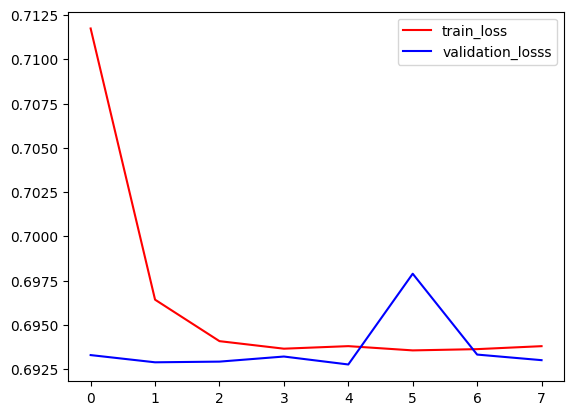

In [39]:
plt.plot(history.history['loss'],color='red',label='train_loss')
plt.plot(history.history['val_loss'],color='blue',label='validation_losss')
plt.legend()
plt.show()

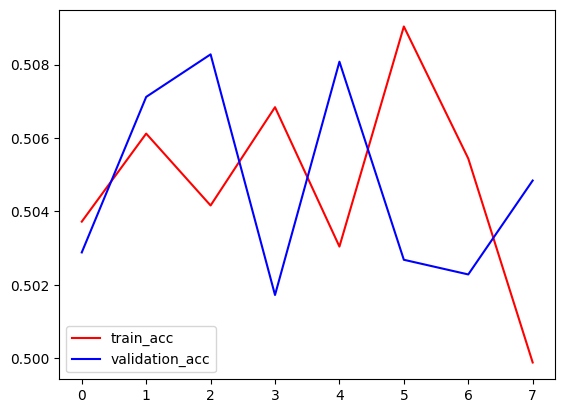

In [41]:
plt.plot(history.history['accuracy'],color='red',label='train_acc')
plt.plot(history.history['val_accuracy'],color='blue',label='validation_acc')
plt.legend()
plt.show()